In [27]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import display, HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy
import seaborn as sns
from numba import set_num_threads
from itertools import product
from tqdm import tqdm
from collections import defaultdict
import copy

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

set_num_threads(14)  # Ajusta al nº de núcleos que quieras

# 2D Navier–Stokes (vorticity–streamfunction) + POD-ROM + Data Assimilation

This notebook builds a *ground truth* CFD solution of a 2D incompressible flow
using the **vorticity–streamfunction** formulation of Navier–Stokes.

On top of this ground truth, we:

1. Build a **POD-based Reduced Order Model (ROM)**.
2. Implement several **Data Assimilation (DA)** methods in the reduced space:
   - Nudging
   - Kalman Filter
   - Ensemble Kalman Filter (EnKF)
   - 4DVar (on a short time window)

The physical scenario is inspired by a **suddenly accelerated flat plate inside a channel**, 
which generates separation and wake structures.


In [28]:
# Domain
Nx, Ny = 128, 64
Lx, Ly = 2.0, 1.0
dx, dy = Lx / Nx, Ly / Ny

# ensure dx ~ dy
print("dx, dy =", dx, dy)

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
Xg, Yg = np.meshgrid(x, y, indexing="ij")

# Time
dt = 8e-4
n_steps = 300    # puedes bajarlo a 1500 para ir más rápido
save_every = 10   # guardamos snapshots cada N pasos

# Physical parameters
Re = 800.0
nu = 1.0 / Re

# Fields
omega = np.zeros((Nx, Ny))
psi   = np.zeros((Nx, Ny))
u     = np.zeros((Nx, Ny))
v     = np.zeros((Nx, Ny))
p     = np.zeros((Nx, Ny))  # pressure


dx, dy = 0.015625 0.015625


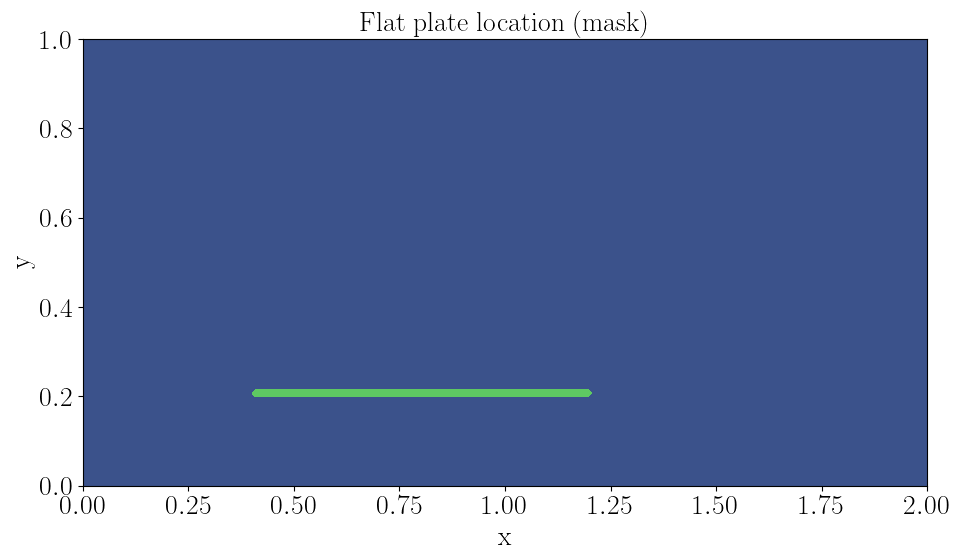

In [29]:
# Flat plate mask (solid region) inside the channel
plate_mask = np.zeros((Nx, Ny), dtype=bool)

# Plate: thin horizontal segment at y ~ 0.2, for x in [0.4, 1.2]
for i in range(Nx):
    for j in range(Ny):
        if 0.4 < Xg[i,j] < 1.2 and 0.20 < Yg[i,j] < 0.22:
            plate_mask[i,j] = True

plt.figure(figsize=(10,6))
plt.contourf(Xg, Yg, plate_mask.astype(float), levels=[-0.5,0.5,1.5])
plt.title("Flat plate location (mask)")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()
plt.show()


In [30]:
def laplacian(f):
    return (
        (np.roll(f,1,0) - 2*f + np.roll(f,-1,0)) / dx**2 +
        (np.roll(f,1,1) - 2*f + np.roll(f,-1,1)) / dy**2
    )

def jacobian_arakawa(psi, omega):
    """Arakawa Jacobian J(psi, omega) for stability."""
    jp = ( (np.roll(psi, -1, 0) - np.roll(psi, 1, 0)) *
           (np.roll(omega, -1, 1) - np.roll(omega, 1, 1)) -
           (np.roll(psi, -1, 1) - np.roll(psi, 1, 1)) *
           (np.roll(omega, -1, 0) - np.roll(omega, 1, 0)) ) / (4*dx*dy)
    return jp

def solve_poisson_psi(omega, psi, iters=200):
    """Solve ∇² psi = -omega with Jacobi iteration."""
    for _ in range(iters):
        psi_new = 0.25 * (
            np.roll(psi,1,0) + np.roll(psi,-1,0) +
            np.roll(psi,1,1) + np.roll(psi,-1,1) +
            dx*dy * (-omega)
        )
        # Dirichlet psi=0 on walls and plate
        psi_new[0,:] = 0.0
        psi_new[-1,:] = 0.0
        psi_new[:,0] = 0.0
        psi_new[:,-1] = 0.0
        psi_new[plate_mask] = 0.0

        psi = psi_new
    return psi


In [31]:
def compute_pressure_poisson(u, v, iters=600, tol=1e-6):
    """
    Solve ∇² p = -∇·[(u·∇)u] to obtain a physically consistent pressure field.
    """

    # 1. First derivatives
    dudx = (np.roll(u, -1, 0) - np.roll(u, 1, 0)) / (2*dx)
    dudy = (np.roll(u, -1, 1) - np.roll(u, 1, 1)) / (2*dy)
    dvdx = (np.roll(v, -1, 0) - np.roll(v, 1, 0)) / (2*dx)
    dvdy = (np.roll(v, -1, 1) - np.roll(v, 1, 1)) / (2*dy)

    # Convective acceleration components
    conv_x = u * dudx + v * dudy
    conv_y = u * dvdx + v * dvdy

    # Divergence of convective terms
    dconvx_dx = (np.roll(conv_x, -1, 0) - np.roll(conv_x, 1, 0)) / (2*dx)
    dconvy_dy = (np.roll(conv_y, -1, 1) - np.roll(conv_y, 1, 1)) / (2*dy)

    RHS = -(dconvx_dx + dconvy_dy)

    # Poisson solve: ∇² p = RHS
    p = np.zeros_like(u)
    for k in range(iters):
        p_old = p.copy()
        p = 0.25 * (
            np.roll(p,1,0) + np.roll(p,-1,0) +
            np.roll(p,1,1) + np.roll(p,-1,1) -
            dx*dy * RHS
        )

        # Neumann-like BC on boundaries
        p[0,:]  = p[1,:]
        p[-1,:] = p[-2,:]
        p[:,0]  = p[:,1]
        p[:,-1] = p[:,-2]

        # Inside plate: smooth
        p[plate_mask] = np.mean(p[~plate_mask])

        if np.linalg.norm(p - p_old) < tol:
            break

    return p


In [32]:
def apply_velocity_bcs(u, v, t):
    """
    Inflow impulsivo en x=0, paredes no deslizantes, salida Neumann y placa no-slip.
    """
    # Inflow (left boundary): ramp in time
    inflow = np.tanh(30 * (t - 0.05))  # 0 → 1 a ~t=0.05-0.15
    u[0,:] = inflow
    v[0,:] = 0.0

    # Top/bottom walls: no-slip
    u[:,0]  = 0.0; v[:,0]  = 0.0
    u[:,-1] = 0.0; v[:,-1] = 0.0

    # Outflow: Neumann (copy from interior)
    u[-1,:] = u[-2,:]
    v[-1,:] = v[-2,:]

    # Plate: no-slip
    u[plate_mask] = 0.0
    v[plate_mask] = 0.0

def compute_vorticity_from_psi(psi):
    """
    ω = ∂v/∂x - ∂u/∂y
    with u = ψ_y, v = -ψ_x
    """
    u_loc =  (np.roll(psi, -1, 1) - np.roll(psi, 1, 1)) / (2*dy)
    v_loc = -(np.roll(psi, -1, 0) - np.roll(psi, 1, 0)) / (2*dx)
    omega_loc = (np.roll(v_loc, -1, 0) - np.roll(v_loc, 1, 0)) / (2*dx) - \
                (np.roll(u_loc, -1, 1) - np.roll(u_loc, 1, 1)) / (2*dy)
    return u_loc, v_loc, omega_loc


In [33]:
snapshots = []   # each snapshot: flattened [u; v; p]
times = []

print_every = 200

for n in range(n_steps):
    t = n * dt

    # Solve for psi from vorticity
    psi = solve_poisson_psi(omega, psi, iters=80)

    # Velocity from psi
    u =  (np.roll(psi, -1, 1) - np.roll(psi, 1, 1)) / (2*dy)
    v = -(np.roll(psi, -1, 0) - np.roll(psi, 1, 0)) / (2*dx)

    # Apply BCs
    apply_velocity_bcs(u, v, t)

    # Compute vorticity from updated velocity (for consistency near walls/plate)
    # (simple approximation)
    omega = (np.roll(v, -1, 0) - np.roll(v, 1, 0)) / (2*dx) - \
            (np.roll(u, -1, 1) - np.roll(u, 1, 1)) / (2*dy)

    # Time update of vorticity: ω_t + J(ψ,ω) = ν ∇²ω
    conv = jacobian_arakawa(psi, omega)
    diff = nu * laplacian(omega)
    omega = omega + dt * (-conv + diff)

    # Enforce zero vorticity in plate region (solid)
    omega[plate_mask] = 0.0

    # Save snapshots
    if n % save_every == 0:
        # recompute psi, velocity high-quality
        psi = solve_poisson_psi(omega, psi, iters=80)
        u =  (np.roll(psi, -1, 1) - np.roll(psi, 1, 1)) / (2*dy)
        v = -(np.roll(psi, -1, 0) - np.roll(psi, 1, 0)) / (2*dx)
        apply_velocity_bcs(u, v, t)

        # compute physical pressure
        p = compute_pressure_poisson(u, v, iters=400)

        # flatten and stack u,v,p
        snapshot_vec = np.concatenate([u.flatten(), v.flatten(), p.flatten()])
        snapshots.append(snapshot_vec)
        times.append(t)

    if n % print_every == 0:
        print(f"Step {n}/{n_steps}, t={t:.3f}")

snapshots = np.array(snapshots)   # shape (n_snaps, 3*Nx*Ny)
times = np.array(times)
print("Snapshots shape:", snapshots.shape)


Step 0/300, t=0.000
Step 200/300, t=0.160
Snapshots shape: (30, 24576)


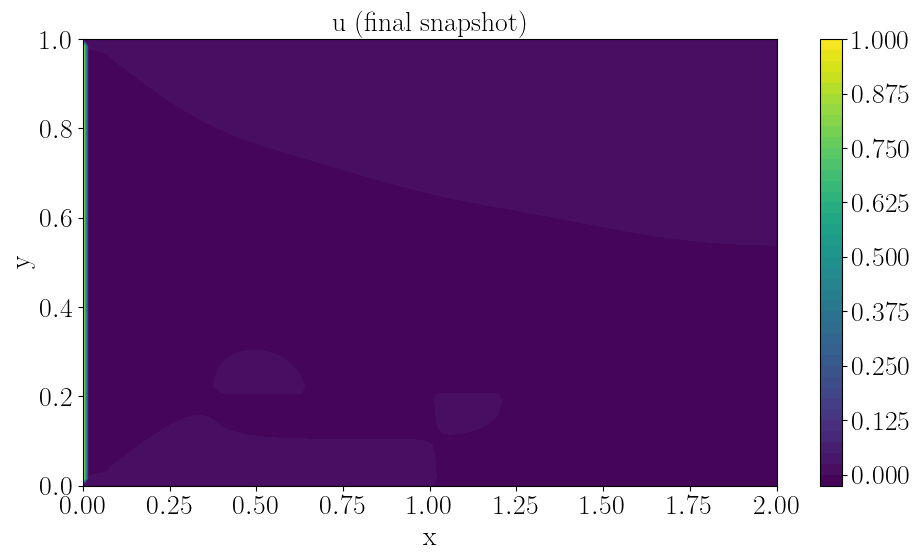

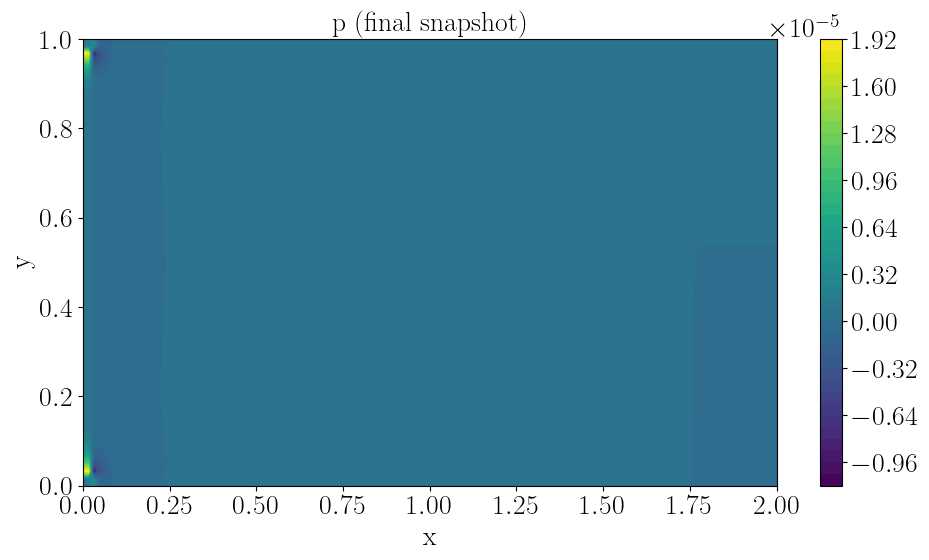

In [34]:
def plot_field(field_flat, title=""):
    field = field_flat.reshape(Nx, Ny)
    plt.figure(figsize=(10,6))
    plt.contourf(Xg, Yg, field, levels=40)
    plt.colorbar()
    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")
    plt.tight_layout()
    plt.show()

# last snapshot: extract u, v, p
n_state = Nx * Ny
u_last = snapshots[-1, 0:n_state]
v_last = snapshots[-1, n_state:2*n_state]
p_last = snapshots[-1, 2*n_state:3*n_state]

plot_field(u_last, "u (final snapshot)")
plot_field(p_last, "p (final snapshot)")


In [35]:
# Data matrix: each column is a snapshot vector [u;v;p]
X_data = snapshots.T   # shape (3*Nx*Ny, n_snaps)
n_state_full, n_snaps = X_data.shape
print("X_data:", X_data.shape)

# Centering
center_data = True
if center_data:
    mean_field = np.mean(X_data, axis=1, keepdims=True)
    X = X_data - mean_field
else:
    mean_field = np.zeros((n_state_full, 1))
    X = X_data


X_data: (24576, 30)


Computing SVD for POD...


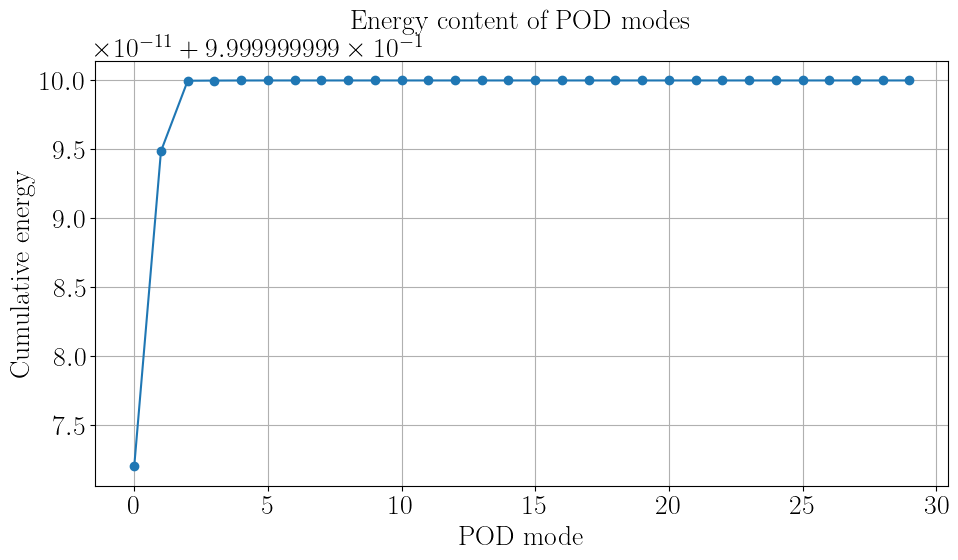

Phi: (24576, 20) A: (20, 30)


In [36]:
print("Computing SVD for POD...")
U, S, Vt = np.linalg.svd(X, full_matrices=False)

energy = S**2 / np.sum(S**2)
cum_energy = np.cumsum(energy)

plt.figure(figsize=(10,6))
plt.plot(cum_energy, "-o")
plt.xlabel("POD mode")
plt.ylabel("Cumulative energy")
plt.title("Energy content of POD modes")
plt.grid(True)
plt.tight_layout()
plt.show()

# choose reduced dimension
r = 20
Phi = U[:, :r]                 # spatial modes (3*Nx*Ny, r)
Sigma_r = np.diag(S[:r])
V_r = Vt[:r, :]                # temporal (r, n_snaps)
A = Sigma_r @ V_r              # POD coefficients (r, n_snaps)

print("Phi:", Phi.shape, "A:", A.shape)


In [37]:
def reconstruct_full_state(r_vec):
    """
    r_vec: reduced state (r,)
    returns: full state [u;v;p] flattened (3*Nx*Ny,)
    """
    return (Phi @ r_vec) + mean_field.flatten()

def split_uvp(state_flat):
    u_flat = state_flat[0:n_state]
    v_flat = state_flat[n_state:2*n_state]
    p_flat = state_flat[2*n_state:3*n_state]
    return u_flat, v_flat, p_flat


F_rom shape: (20, 20)


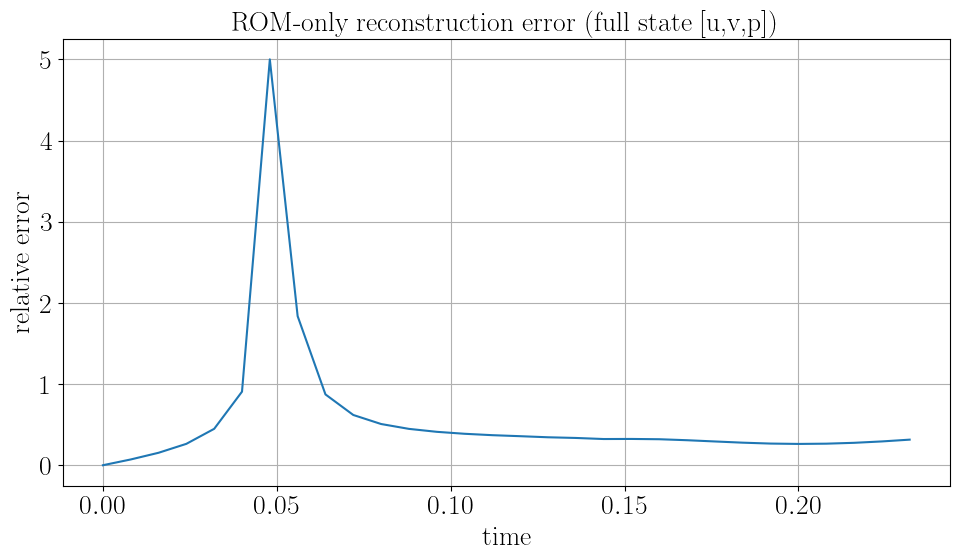

In [38]:
# ROM: a_{k+1} = F_rom a_k
A_k  = A[:, :-1]   # (r, n_snaps-1)
A_k1 = A[:, 1:]    # (r, n_snaps-1)

F_rom = A_k1 @ A_k.T @ np.linalg.inv(A_k @ A_k.T)
print("F_rom shape:", F_rom.shape)

# Quick test: simulate ROM only
A_rom = np.zeros_like(A)
A_rom[:,0] = A[:,0]  # same initial condition

for k in range(1, n_snaps):
    A_rom[:,k] = F_rom @ A_rom[:,k-1]

# ROM error vs truth for full [u,v,p]
err_rom = np.zeros(n_snaps)
for k in range(n_snaps):
    full_rom = reconstruct_full_state(A_rom[:,k])
    full_true = X_data[:,k]
    err_rom[k] = np.linalg.norm(full_rom - full_true) / np.linalg.norm(full_true)

plt.figure(figsize=(10,6))
plt.plot(times, err_rom)
plt.xlabel("time")
plt.ylabel("relative error")
plt.title("ROM-only reconstruction error (full state [u,v,p])")
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
# Build sensor locations on plate surface (just above plate)
plate_surface = []
for i in range(Nx):
    for j in range(Ny-1):
        if plate_mask[i,j] and not plate_mask[i,j+1]:
            plate_surface.append((i, j+1))

# Downsample sensors (every 4th point)
plate_surface = plate_surface[::4]
print("Number of plate sensors:", len(plate_surface))

# Build H_x for u-velocity at these points
n_sensors = len(plate_surface)
H_x = np.zeros((n_sensors, 3*Nx*Ny))

for si, (ix, iy) in enumerate(plate_surface):
    idx_u = ix * Ny + iy  # index in the u-block
    H_x[si, idx_u] = 1.0

# Observation operator in reduced space
H_tilde = H_x @ Phi      # (n_sensors, r)
print("H_tilde:", H_tilde.shape)

# True reduced trajectories
r_true = A  # rename for clarity: shape (r, n_snaps)

# Build "truth" sensor data from ROM truth (no noise yet)
Y_truth = H_tilde @ r_true  # (n_sensors, n_snaps)


Number of plate sensors: 13
H_tilde: (13, 20)


In [40]:
obs_noise_std = 0.02  # students can play with this

noise = obs_noise_std * np.random.randn(n_sensors, n_snaps)
Y_obs = Y_truth + noise
print("Y_obs shape:", Y_obs.shape)


Y_obs shape: (13, 30)


In [41]:
class NudgingAssimilator:
    def __init__(self, F, H_tilde, gamma=0.1):
        self.F = F
        self.H = H_tilde
        self.gamma = gamma

    def step(self, r_prev, y_obs):
        r_pred = self.F @ r_prev
        y_pred = self.H @ r_pred
        innovation = y_obs - y_pred
        r_upd = r_pred + self.gamma * (self.H.T @ innovation)
        return r_upd

class KalmanAssimilator:
    def __init__(self, F, H_tilde, b_std=1e-3, r_std=0.02):
        self.F = F
        self.H = H_tilde
        self.n_r = F.shape[0]
        self.n_s = H_tilde.shape[0]

        self.B = (b_std**2) * np.eye(self.n_r)
        self.R = (r_std**2) * np.eye(self.n_s)
        self.P = np.eye(self.n_r) * 1.0
        self.I = np.eye(self.n_r)

    def step(self, r_prev, y_obs):
        # predict
        r_pred = self.F @ r_prev
        P_pred = self.F @ self.P @ self.F.T + self.B

        # update
        y_pred = self.H @ r_pred
        S = self.H @ P_pred @ self.H.T + self.R
        K = P_pred @ self.H.T @ np.linalg.inv(S)

        innovation = y_obs - y_pred
        r_upd = r_pred + K @ innovation
        self.P = (self.I - K @ self.H) @ P_pred
        return r_upd

class EnKFAssimilator:
    def __init__(self, F, H_tilde, n_ens=40, b_std=1e-3, r_std=0.02):
        self.F = F
        self.H = H_tilde
        self.n_r = F.shape[0]
        self.n_s = H_tilde.shape[0]
        self.n_ens = n_ens
        self.b_std = b_std
        self.r_std = r_std

        self.R = (r_std**2) * np.eye(self.n_s)
        self.ens = 0.1 * np.random.randn(self.n_r, n_ens)

    def step(self, y_obs):
        # forecast ensemble
        for j in range(self.n_ens):
            self.ens[:,j] = self.F @ self.ens[:,j] + \
                            self.b_std * np.random.randn(self.n_r)

        r_mean = np.mean(self.ens, axis=1, keepdims=True)
        A = self.ens - r_mean

        Y_ens = self.H @ self.ens
        y_mean = np.mean(Y_ens, axis=1, keepdims=True)
        Y_ano = Y_ens - y_mean

        Pf = (A @ A.T) / (self.n_ens - 1)
        Py = (Y_ano @ Y_ano.T) / (self.n_ens - 1) + self.R
        K = Pf @ self.H.T @ np.linalg.inv(Py)

        y_pert = y_obs.reshape(-1,1) + \
                 self.r_std * np.random.randn(self.n_s, self.n_ens)

        self.ens = self.ens + K @ (y_pert - Y_ens)
        r_an = np.mean(self.ens, axis=1)
        return r_an

class Var4DAssimilator:
    """
    Simple 4DVar on a time window for the reduced model:
    r_{k+1} = F r_k,  y_k = H r_k.
    """
    def __init__(self, F, H_tilde, b_std=0.1, r_std=0.02, window_size=20):
        self.F = F
        self.H = H_tilde
        self.n_r = F.shape[0]
        self.n_s = H_tilde.shape[0]
        self.N = window_size

        self.B = (b_std**2) * np.eye(self.n_r)
        self.R = (r_std**2) * np.eye(self.n_s)

    def build_H_stack(self):
        H_list = []
        F_power = np.eye(self.n_r)
        for k in range(self.N):
            H_list.append(self.H @ F_power)
            F_power = self.F @ F_power
        H_stack = np.vstack(H_list)
        return H_stack

    def assimilate(self, r_b, y_window):
        H_stack = self.build_H_stack()
        y_stack = y_window.reshape(-1)

        B_inv = np.linalg.inv(self.B)
        sigma2 = self.R[0,0]
        A_mat = B_inv + (1.0/sigma2) * (H_stack.T @ H_stack)
        b_vec = B_inv @ r_b + (1.0/sigma2) * (H_stack.T @ y_stack)

        r0_opt = np.linalg.solve(A_mat, b_vec)

        traj = []
        r_k = r0_opt.copy()
        for k in range(self.N):
            traj.append(r_k.copy())
            r_k = self.F @ r_k
        traj = np.array(traj)
        return r0_opt, traj


In [42]:
def rmse_full_state(r_est, k_idx):
    """
    RMSE over full [u,v,p] reconstructed state vs truth at snapshot k_idx.
    """
    full_est = reconstruct_full_state(r_est)
    full_true = X_data[:,k_idx]
    return np.linalg.norm(full_est - full_true) / np.linalg.norm(full_true)

def run_sequential_DA(method="nudging",
                      gamma=0.1,
                      b_std=1e-3,
                      r_std=0.02,
                      n_ens=40,
                      obs_noise_std=0.02,
                      r0_perturb=0.5):
    """
    Run a sequential DA experiment (nudging, Kalman, EnKF or none) in reduced space.
    """

    n_r, nT = r_true.shape

    # Observations (regenerate with noise for reproducibility)
    noise = obs_noise_std * np.random.randn(n_sensors, nT)
    Y_obs_local = Y_truth + noise

    # Initial condition
    r0 = r_true[:,0] + r0_perturb * np.random.randn(n_r)

    if method == "nudging":
        assim = NudgingAssimilator(F_rom, H_tilde, gamma=gamma)
        r_k = r0.copy()
        label = "Nudging"
    elif method == "kalman":
        assim = KalmanAssimilator(F_rom, H_tilde, b_std=b_std, r_std=r_std)
        r_k = r0.copy()
        label = "Kalman"
    elif method == "enkf":
        assim = EnKFAssimilator(F_rom, H_tilde, n_ens=n_ens,
                                b_std=b_std, r_std=r_std)
        assim.ens += r0.reshape(-1,1)
        r_k = np.mean(assim.ens, axis=1)
        label = "EnKF"
    elif method == "none":
        assim = None
        r_k = r0.copy()
        label = "ROM only"
    else:
        raise ValueError("Unknown method")

    r_hist = np.zeros((n_r, nT))
    r_hist[:,0] = r_k
    err_hist = np.zeros(nT)

    for k in range(1, nT):
        if method == "none":
            r_k = F_rom @ r_k
        elif method in ("nudging", "kalman"):
            r_k = assim.step(r_k, Y_obs_local[:,k])
        elif method == "enkf":
            r_k = assim.step(Y_obs_local[:,k])

        r_hist[:,k] = r_k
        err_hist[k] = rmse_full_state(r_k, k)

    # baseline pure ROM from same r0
    r_rom = np.zeros_like(r_hist)
    r_rom[:,0] = r0.copy()
    err_rom = np.zeros(nT)
    r_k2 = r0.copy()
    for k in range(1, nT):
        r_k2 = F_rom @ r_k2
        r_rom[:,k] = r_k2
        err_rom[k] = rmse_full_state(r_k2, k)

    plt.figure(figsize=(10,6))
    plt.plot(times, err_rom, label="ROM only")
    if method != "none":
        plt.plot(times, err_hist, label=label)
    plt.xlabel("time")
    plt.ylabel("Relative RMSE (full [u,v,p])")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Visualize final snapshot
    full_true_final = X_data[:, -1]
    full_da_final   = reconstruct_full_state(r_hist[:, -1])
    full_rom_final  = reconstruct_full_state(r_rom[:, -1])

    u_true_f, v_true_f, p_true_f = split_uvp(full_true_final)
    u_da_f, v_da_f, p_da_f       = split_uvp(full_da_final)
    u_rom_f, v_rom_f, p_rom_f    = split_uvp(full_rom_final)

    plot_field(u_true_f, "u truth (final)")
    if method != "none":
        plot_field(u_da_f, f"u {label} (final)")
    plot_field(u_rom_f, "u ROM-only (final)")

    return r_hist, err_hist, r_rom, err_rom


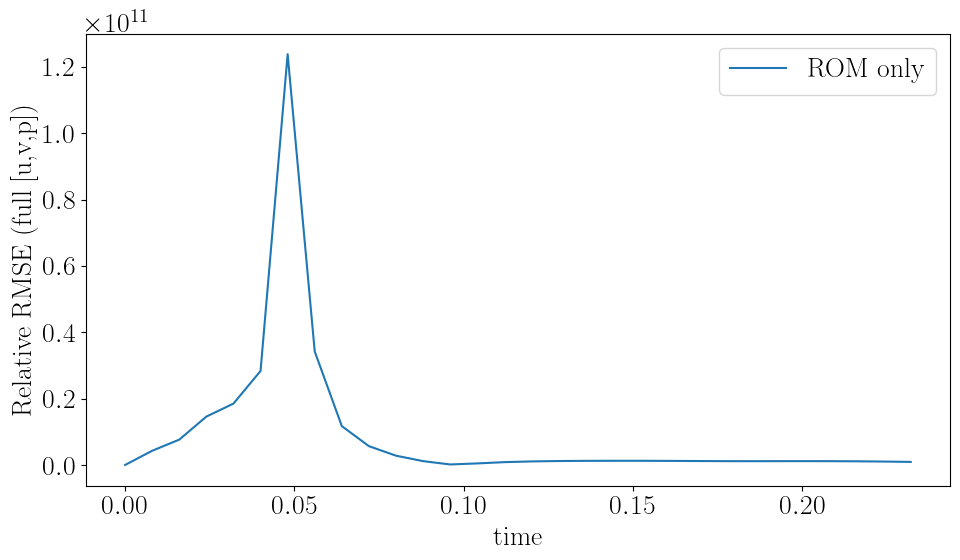

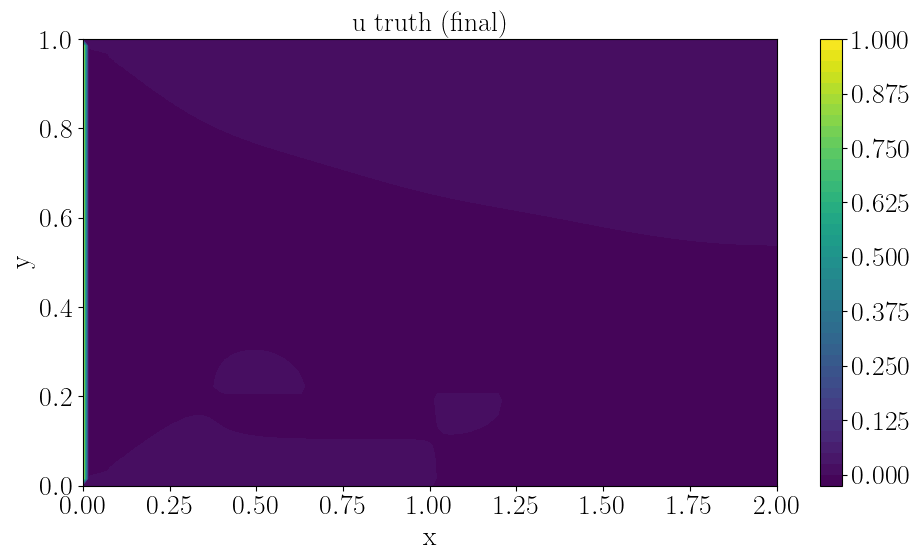

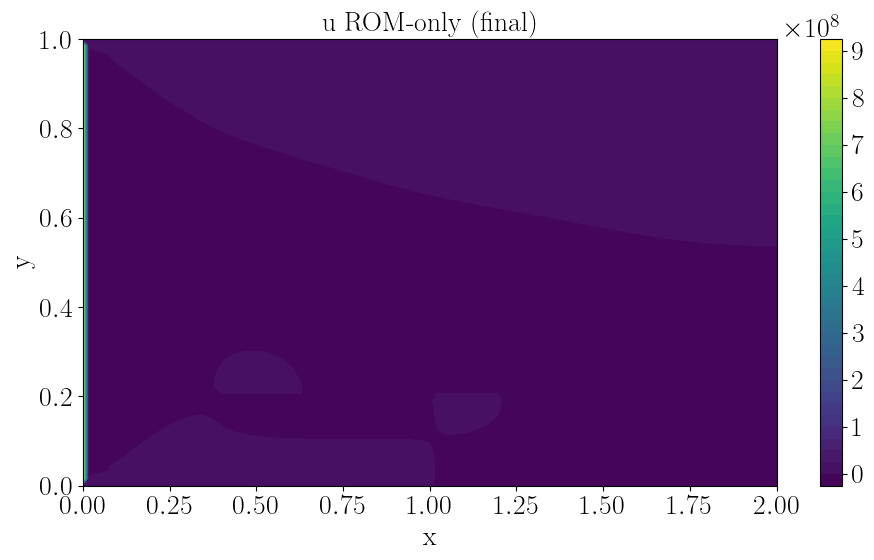

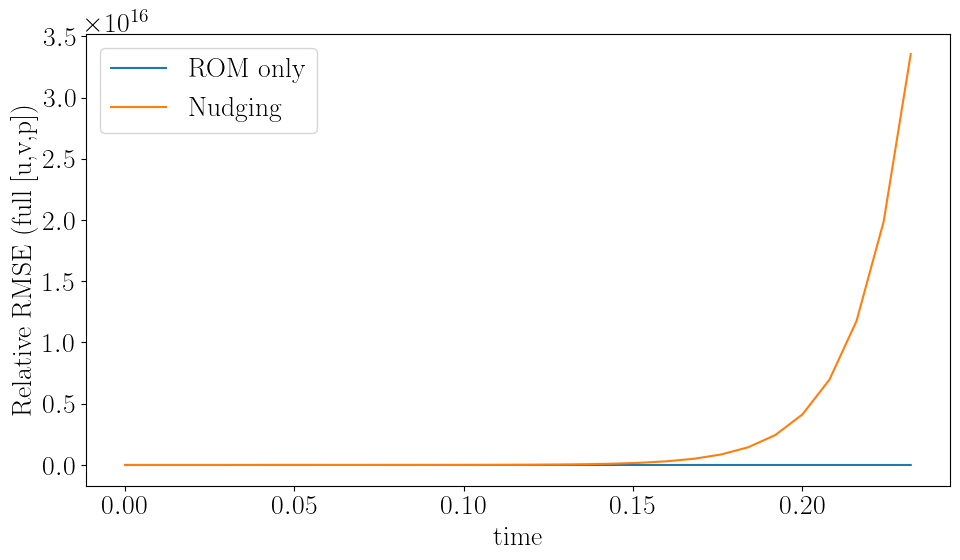

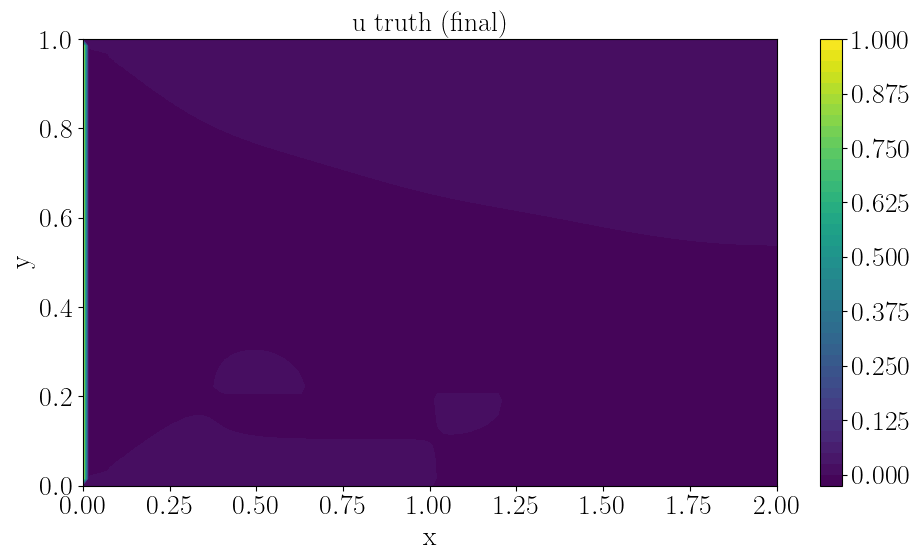

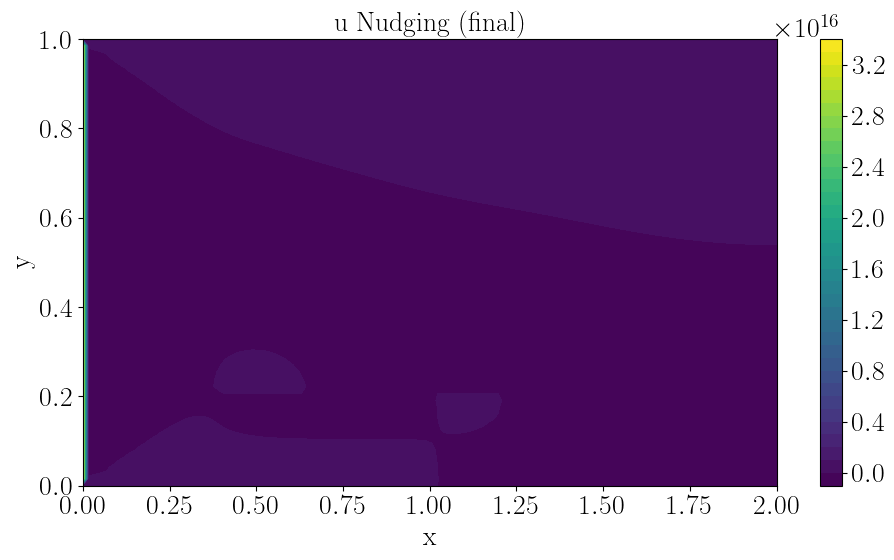

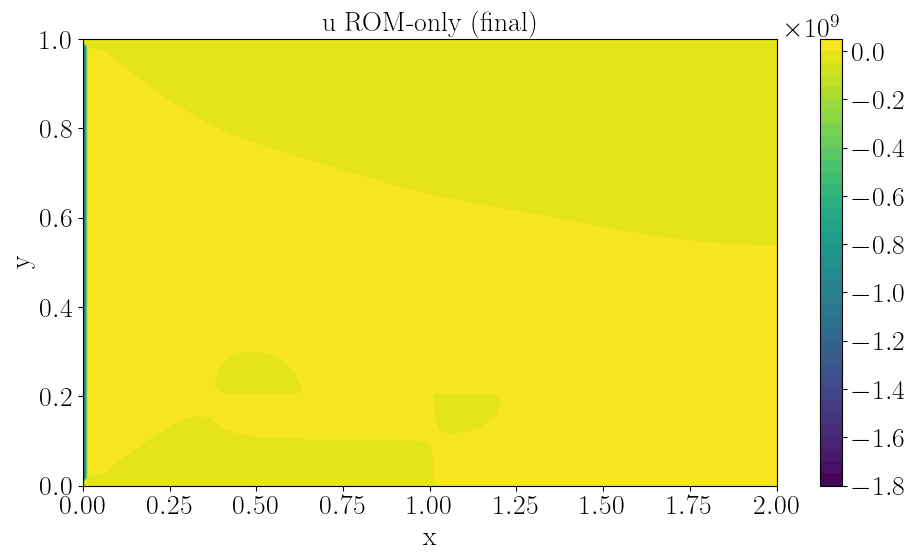

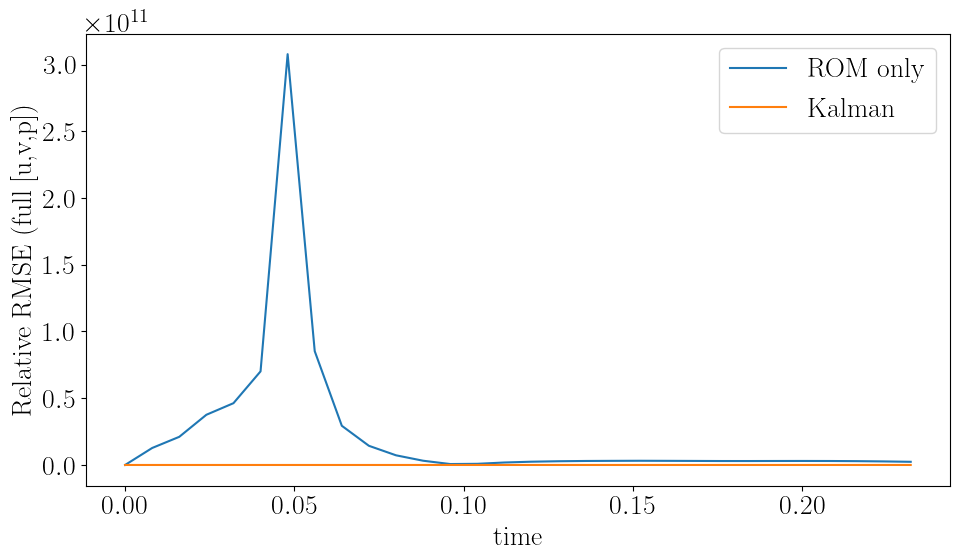

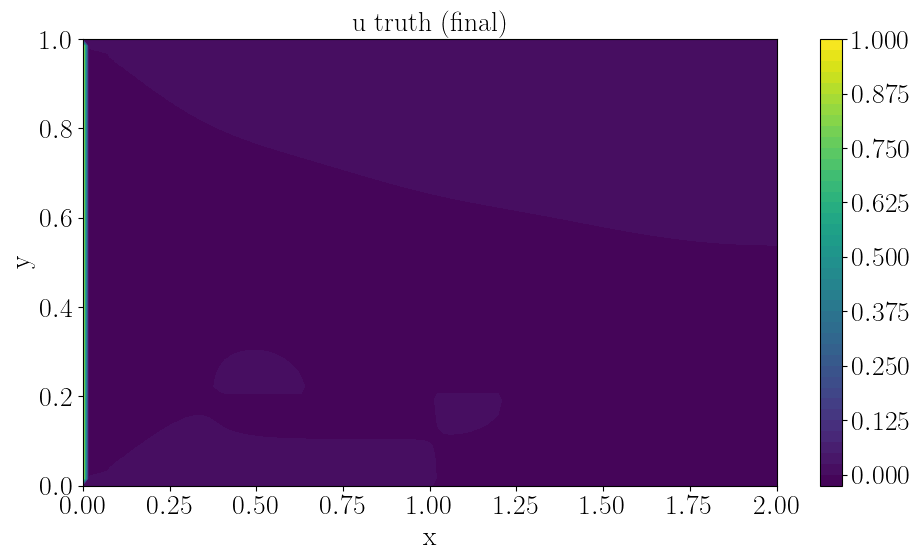

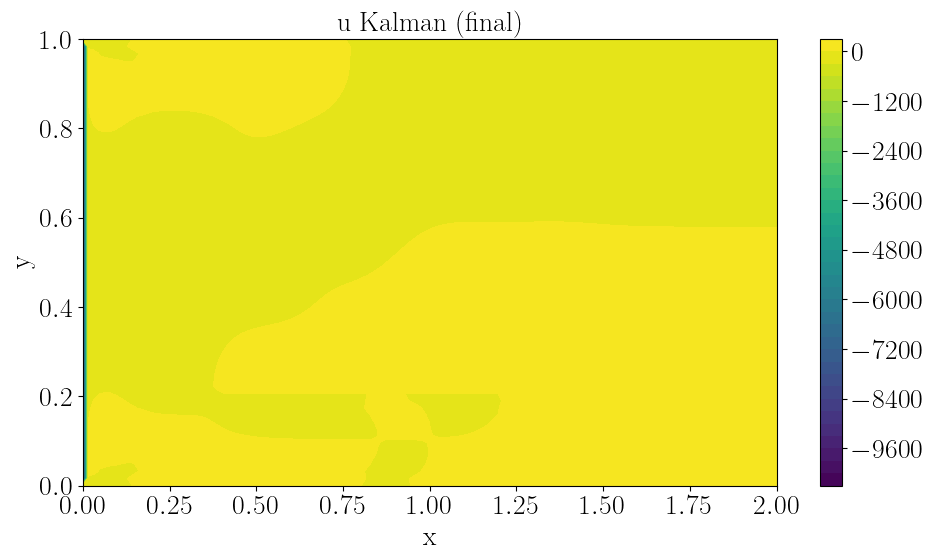

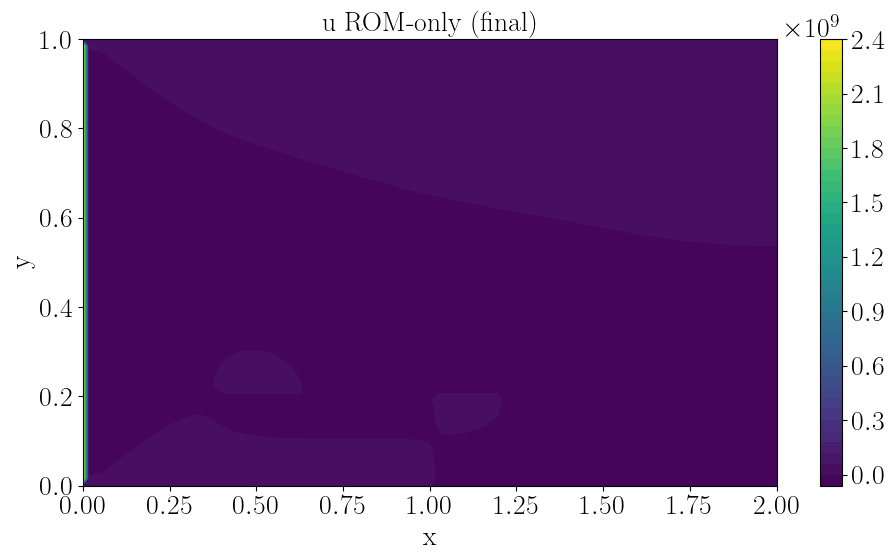

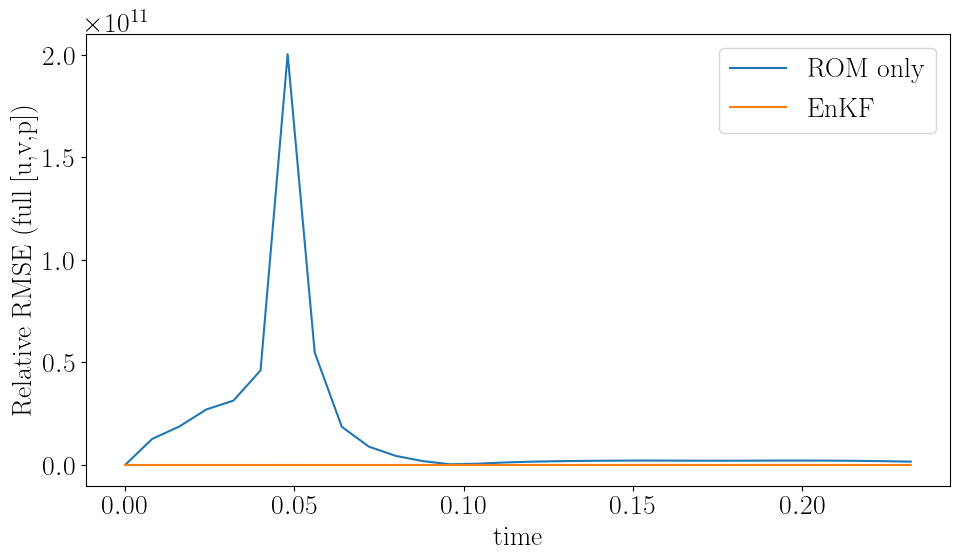

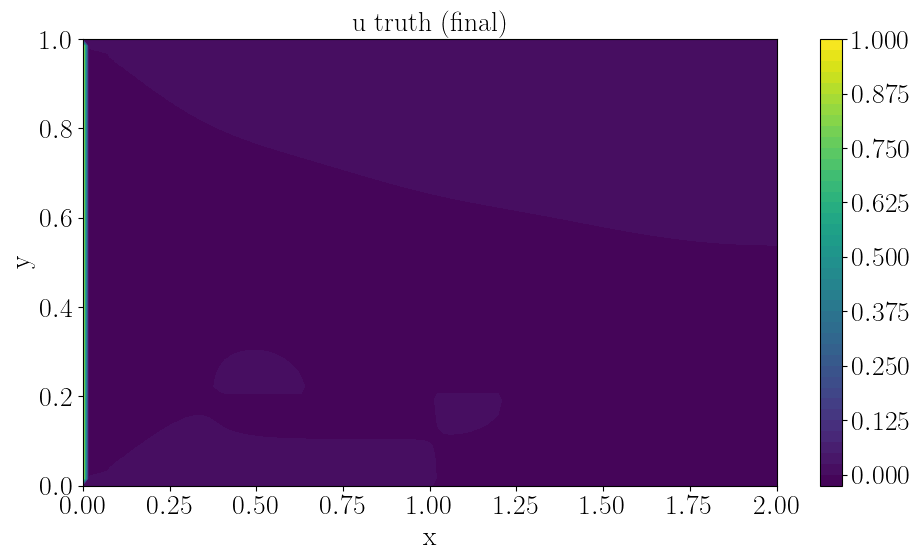

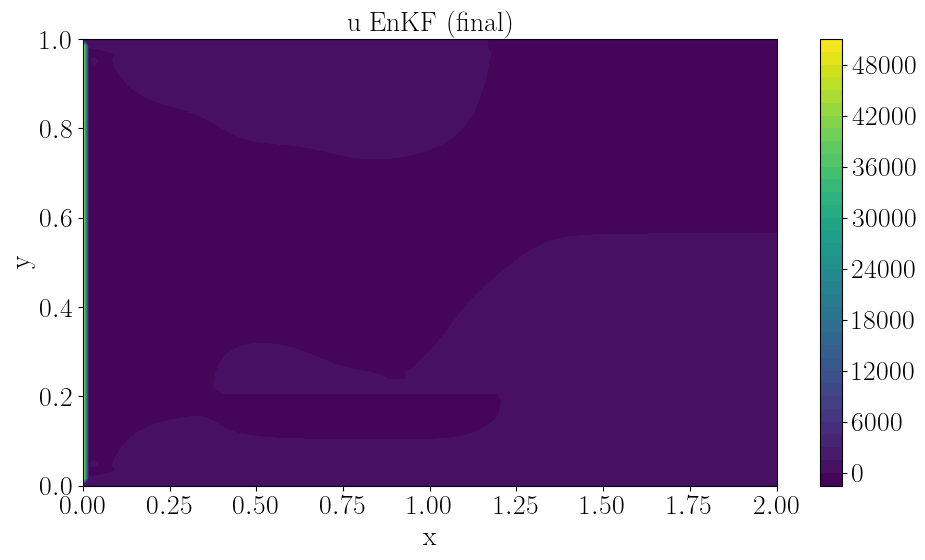

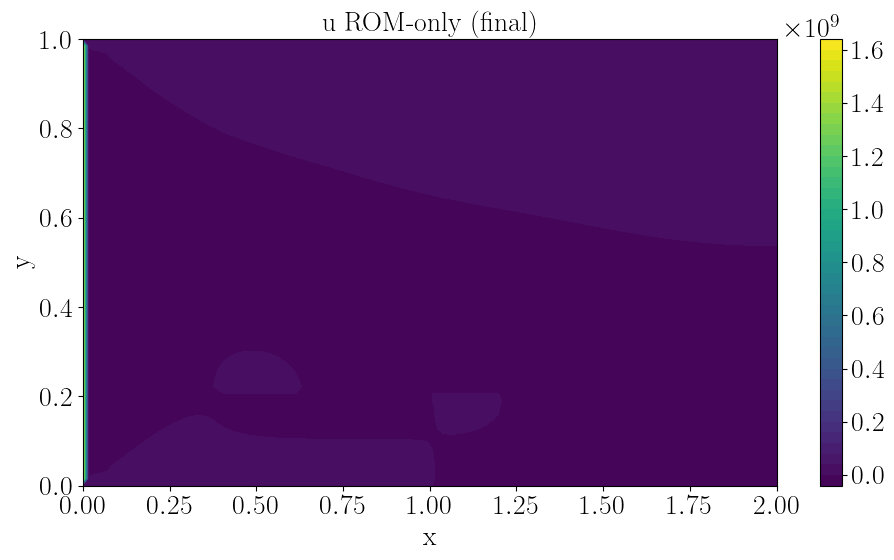

In [43]:
# 1) ROM sin asimilación
_ = run_sequential_DA(method="none",
                      r0_perturb=0.5)

# 2) Nudging
_ = run_sequential_DA(method="nudging",
                      gamma=0.05,
                      obs_noise_std=0.02,
                      r0_perturb=0.5)

# 3) Kalman
_ = run_sequential_DA(method="kalman",
                      b_std=1e-3,
                      r_std=0.02,
                      obs_noise_std=0.02,
                      r0_perturb=0.5)

# 4) EnKF
_ = run_sequential_DA(method="enkf",
                      n_ens=40,
                      b_std=1e-3,
                      r_std=0.02,
                      obs_noise_std=0.02,
                      r0_perturb=0.5)
